# 최종 데이터셋 EDA — 데이터 선정·전처리 검증

**목적**: `docs/데이터_선정결정.md`에 따른 수집·전처리 결과를 검증하고, 실험 리포트 **섹션 2 (데이터 수집 및 전처리)**용 기초 자료를 생성합니다.

**근거 문서**: [데이터_선정결정.md](../docs/데이터_선정결정.md), [data_interface.md](../docs/data_interface.md), [walk_forward_plan.md](../docs/walk_forward_plan.md)

**선행 조건** (parquet 미생성 시):
```bash
.venv/bin/python -m src.data.collector
```

> **주의**: `features.parquet`은 전체 기간 Z-score가 적용된 **legacy/EDA 전용** 산출물입니다. Walk-Forward RL 학습·백테스트에는 `raw_features.parquet`과 윈도우별 `data/processed/scalers/{window}_feature_stats.json`을 사용합니다.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

# --- 한글 폰트 ---
KOREAN_FONT_CANDIDATES = ["AppleGothic", "NanumGothic", "Malgun Gothic", "Arial Unicode MS"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in KOREAN_FONT_CANDIDATES:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

# --- 경로 (cwd = notebooks/) ---
PRICES_PATH = Path("../data/raw/prices.parquet")
RETURNS_PATH = Path("../data/processed/returns.parquet")
RAW_FEATURES_PATH = Path("../data/processed/raw_features.parquet")
FEATURES_PATH = Path("../data/processed/features.parquet")
SCALERS_DIR = Path("../data/processed/scalers")

TICKERS = [
    "SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ", "069500", "114260",
]
EXPECTED_START = pd.Timestamp("2018-01-01")
EXPECTED_END = pd.Timestamp("2025-12-31")

ASSET_GROUPS: dict[str, list[str]] = {
    "미국 주식": ["SPY", "QQQ", "IWM"],
    "글로벌 주식": ["EFA", "EEM"],
    "채권": ["TLT", "114260"],
    "대안": ["GLD", "VNQ"],
    "국내": ["069500"],
}
GROUP_COLORS = {
    "미국 주식": "#1f77b4",
    "글로벌 주식": "#2ca02c",
    "채권": "#9467bd",
    "대안": "#ff7f0e",
    "국내": "#d62728",
}

WINDOWS: list[dict[str, str]] = [
    {
        "name": "W1",
        "train_start": "2018-01-01",
        "train_end": "2021-12-31",
        "test_start": "2022-01-01",
        "test_end": "2022-12-31",
        "regime": "금리 인상·주식·장기채 동반 약세",
        "scaler_key": "w1",
    },
    {
        "name": "W2",
        "train_start": "2019-01-01",
        "train_end": "2022-12-31",
        "test_start": "2023-01-01",
        "test_end": "2023-12-31",
        "regime": "금리 충격 이후 회복장",
        "scaler_key": "w2",
    },
    {
        "name": "W3",
        "train_start": "2020-01-01",
        "train_end": "2023-12-31",
        "test_start": "2024-01-01",
        "test_end": "2024-12-31",
        "regime": "고금리 지속·기술주·AI 랠리",
        "scaler_key": "w3",
    },
    {
        "name": "Final",
        "train_start": "2021-01-01",
        "train_end": "2024-12-31",
        "test_start": "2025-01-01",
        "test_end": "2025-12-31",
        "regime": "최신 시장 구간",
        "scaler_key": "final",
    },
]

TRADING_DAYS = 252


def ticker_group(ticker: str) -> str:
    for group, members in ASSET_GROUPS.items():
        if ticker in members:
            return group
    return "기타"


def slice_period(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    return df.loc[start:end]


def annualized_return(log_returns: pd.Series) -> float:
    return float(log_returns.mean() * TRADING_DAYS)


def annualized_vol(log_returns: pd.Series) -> float:
    return float(log_returns.std(ddof=1) * np.sqrt(TRADING_DAYS))


def max_drawdown(cum_log_returns: pd.Series) -> float:
    wealth = np.exp(cum_log_returns)
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    return float(dd.min())


def equal_weight_portfolio(returns_df: pd.DataFrame) -> pd.Series:
    return returns_df.mean(axis=1)


## 1. 파일 로드


In [2]:
prices = pd.read_parquet(PRICES_PATH)
returns = pd.read_parquet(RETURNS_PATH)
raw_features = pd.read_parquet(RAW_FEATURES_PATH)
features_legacy = pd.read_parquet(FEATURES_PATH)

for df in (prices, returns, raw_features, features_legacy):
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

print("prices         :", prices.shape, prices.index.min().date(), "~", prices.index.max().date())
print("returns        :", returns.shape, returns.index.min().date(), "~", returns.index.max().date())
print("raw_features   :", raw_features.shape, raw_features.index.min().date(), "~", raw_features.index.max().date())
print("features_legacy:", features_legacy.shape, features_legacy.index.min().date(), "~", features_legacy.index.max().date())


prices         : (1899, 10) 2018-01-02 ~ 2025-12-30
returns        : (1898, 10) 2018-01-03 ~ 2025-12-30
raw_features   : (1865, 40) 2018-02-23 ~ 2025-12-30
features_legacy: (1865, 40) 2018-02-23 ~ 2025-12-30


## 2. 선정 명세 준수 체크리스트


In [3]:
checks: list[tuple[str, str, bool]] = []

missing_tickers = [t for t in TICKERS if t not in returns.columns]
checks.append(("자산 수·티커", f"10열, 누락={missing_tickers or '없음'}", len(returns.columns) == 10 and not missing_tickers))

first_date, last_date = returns.index.min(), returns.index.max()
period_ok = (
    first_date <= EXPECTED_START + pd.Timedelta(days=10)
    and last_date >= EXPECTED_END - pd.Timedelta(days=10)
)
checks.append(("기간", f"{first_date.date()} ~ {last_date.date()}", period_ok))

missing_returns = int(returns.isnull().sum().sum())
missing_raw = int(raw_features.isnull().sum().sum())
missing_legacy = int(features_legacy.isnull().sum().sum())
checks.append(("결측치", f"returns={missing_returns}, raw={missing_raw}, legacy={missing_legacy}", missing_returns + missing_raw + missing_legacy == 0))

price_return_rows_ok = prices.shape[0] == returns.shape[0] + 1
checks.append(("로그수익률 행 관계", f"prices {prices.shape[0]}행 = returns {returns.shape[0]}행 + 1", price_return_rows_ok))

macd_warmup_ok = len(raw_features) < len(returns)
checks.append(("MACD warm-up", f"raw_features {len(raw_features)} < returns {len(returns)}", macd_warmup_ok))

rsi_cols = [c for c in raw_features.columns if c.endswith("_RSI")]
rsi = raw_features[rsi_cols]
rsi_ok = float(rsi.min().min()) >= 0 and float(rsi.max().max()) <= 100
checks.append(("RSI (raw 0~100)", f"min={rsi.min().min():.2f}, max={rsi.max().max():.2f}", rsi_ok))

max_abs_return = float(returns.abs().max().max())
checks.append(("극단 로그수익률", f"|r|_max={max_abs_return:.4f} < 0.5", max_abs_return < 0.5))

check_df = pd.DataFrame(checks, columns=["항목", "결과", "통과"])
check_df["통과"] = check_df["통과"].map({True: "✓", False: "✗"})
print(check_df.to_string(index=False))

if (check_df["통과"] == "✗").any():
    raise ValueError("선정 명세 검증 실패 — collector 재실행 또는 데이터 점검 필요")


             항목                               결과 통과
        자산 수·티커                       10열, 누락=없음  ✓
             기간          2018-01-03 ~ 2025-12-30  ✓
            결측치       returns=0, raw=0, legacy=0  ✓
     로그수익률 행 관계 prices 1899행 = returns 1898행 + 1  ✓
   MACD warm-up raw_features 1865 < returns 1898  ✓
RSI (raw 0~100)             min=31.29, max=65.40  ✓
       극단 로그수익률             |r|_max=0.1951 < 0.5  ✓


## 3. prices.parquet


=== prices 기본 정보 ===
shape: (1899, 10)
columns: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD', 'VNQ', '069500', '114260']
결측치 합계: 0


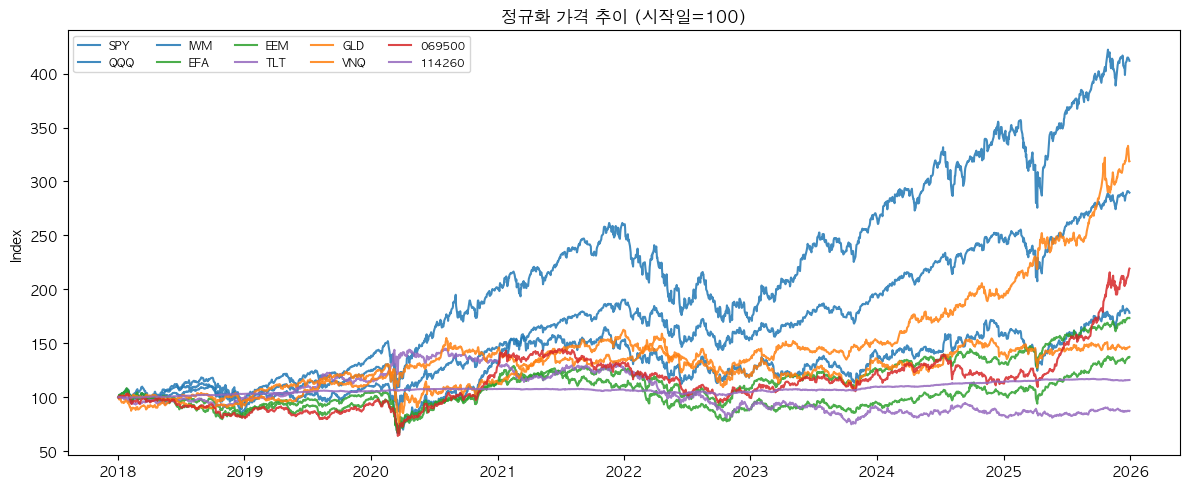

In [4]:
print("=== prices 기본 정보 ===")
print(f"shape: {prices.shape}")
print(f"columns: {list(prices.columns)}")
print(f"결측치 합계: {int(prices.isnull().sum().sum())}")

# index=100 정규화 누적 비교
norm_prices = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.plot(norm_prices.index, norm_prices[ticker], label=ticker, color=GROUP_COLORS[ticker_group(ticker)], alpha=0.85)
ax.set_title("정규화 가격 추이 (시작일=100)")
ax.set_ylabel("Index")
ax.legend(ncol=5, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()
plt.close(fig)


## 4. returns.parquet


=== returns 기술통계 (일간 로그수익률) ===
            mean       std       min       max
SPY     0.000560  0.012573 -0.115886  0.099863
QQQ     0.000746  0.015417 -0.127592  0.113356
IWM     0.000305  0.016015 -0.142335  0.087545
EFA     0.000290  0.011632 -0.116423  0.081332
EEM     0.000167  0.013561 -0.133294  0.077451
TLT    -0.000071  0.010134 -0.069010  0.072503
GLD     0.000611  0.009818 -0.066427  0.047390
VNQ     0.000202  0.014546 -0.195136  0.086147
069500  0.000414  0.012641 -0.096267  0.088770
114260  0.000078  0.001379 -0.009801  0.010853


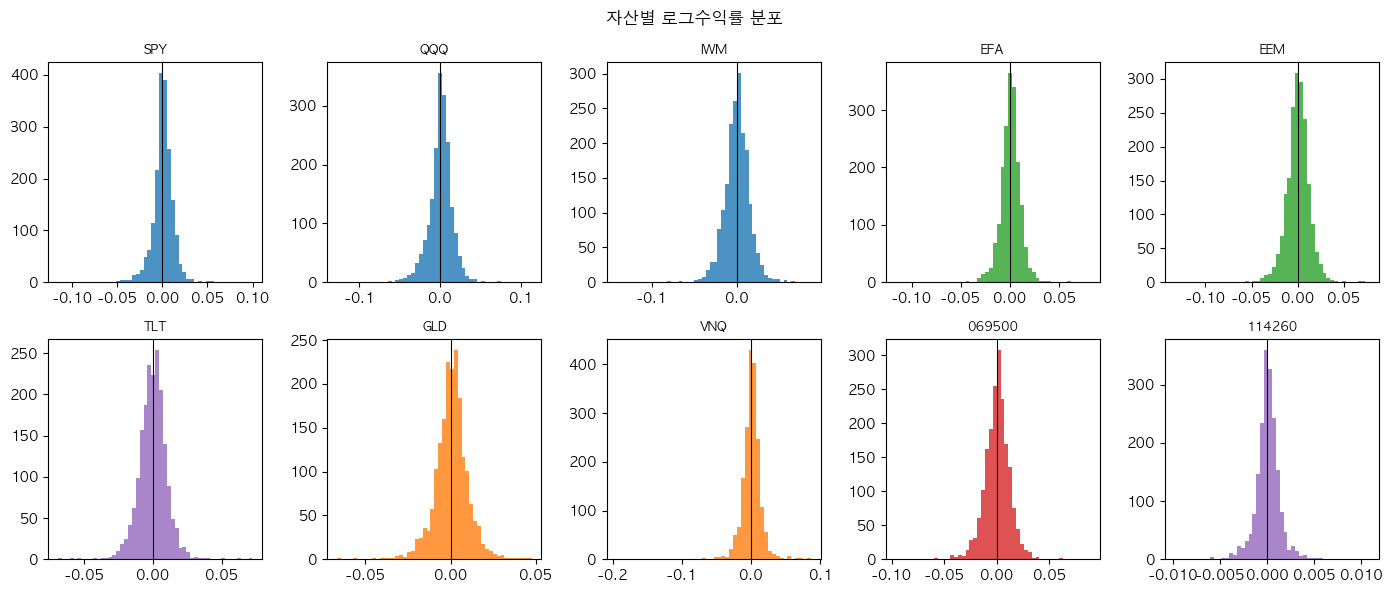

In [5]:
print("=== returns 기술통계 (일간 로그수익률) ===")
print(returns.describe().T[["mean", "std", "min", "max"]])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i, ticker in enumerate(TICKERS):
    axes[i].hist(returns[ticker], bins=50, color=GROUP_COLORS[ticker_group(ticker)], alpha=0.8)
    axes[i].set_title(ticker, fontsize=9)
    axes[i].axvline(0, color="black", linewidth=0.8)
fig.suptitle("자산별 로그수익률 분포")
plt.tight_layout()
plt.show()
plt.close(fig)


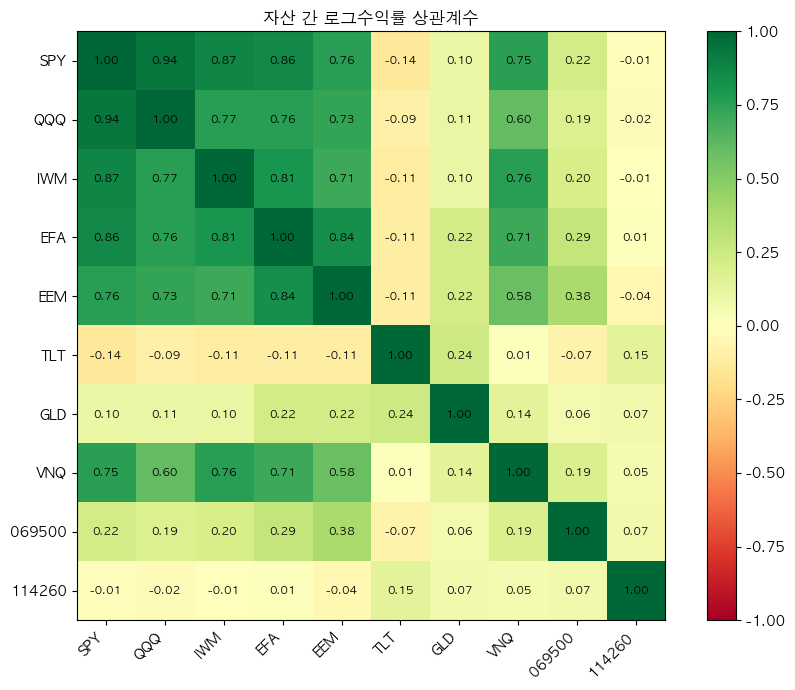

자산군: 미국 주식=3, 글로벌 주식=2, 채권=2, 대안=2, 국내=1
          SPY    QQQ    IWM    EFA    EEM    TLT    GLD    VNQ  069500  114260
SPY     1.000  0.936  0.868  0.859  0.761 -0.143  0.099  0.751   0.222  -0.012
QQQ     0.936  1.000  0.765  0.761  0.731 -0.090  0.106  0.603   0.186  -0.017
IWM     0.868  0.765  1.000  0.809  0.709 -0.114  0.102  0.758   0.204  -0.005
EFA     0.859  0.761  0.809  1.000  0.835 -0.105  0.219  0.710   0.286   0.008
EEM     0.761  0.731  0.709  0.835  1.000 -0.107  0.220  0.582   0.379  -0.040
TLT    -0.143 -0.090 -0.114 -0.105 -0.107  1.000  0.244  0.011  -0.070   0.148
GLD     0.099  0.106  0.102  0.219  0.220  0.244  1.000  0.144   0.061   0.065
VNQ     0.751  0.603  0.758  0.710  0.582  0.011  0.144  1.000   0.188   0.050
069500  0.222  0.186  0.204  0.286  0.379 -0.070  0.061  0.188   1.000   0.070
114260 -0.012 -0.017 -0.005  0.008 -0.040  0.148  0.065  0.050   0.070   1.000


In [6]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("자산 간 로그수익률 상관계수")
plt.tight_layout()
plt.show()
plt.close(fig)

print("자산군:", ", ".join(f"{g}={len(v)}" for g, v in ASSET_GROUPS.items()))
print(corr.round(3))


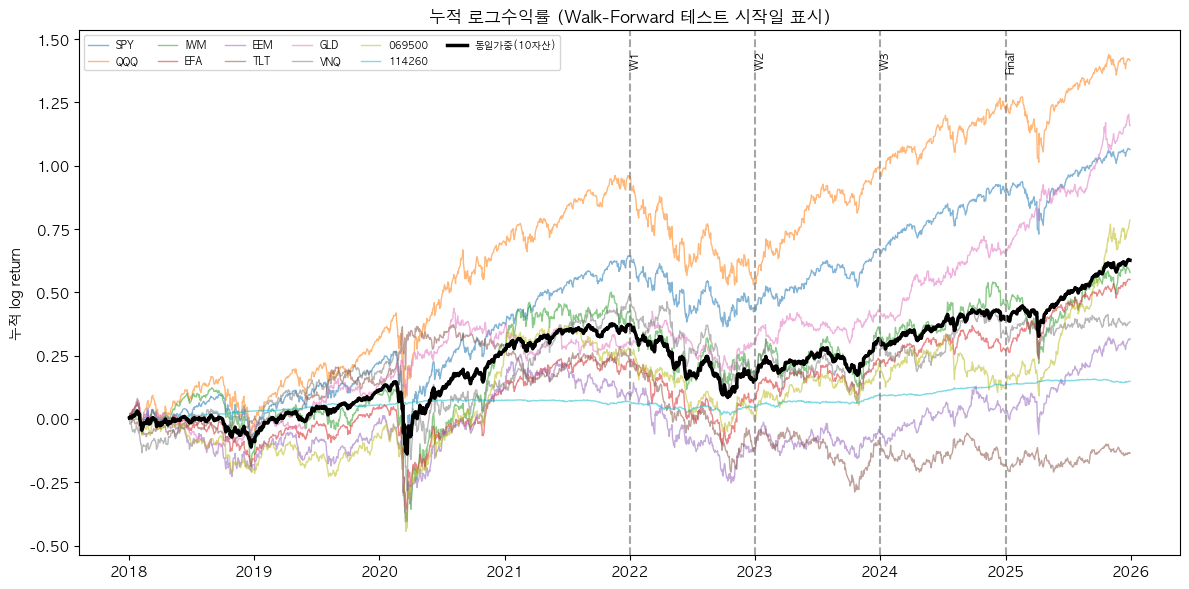

In [7]:
cum_returns = returns.cumsum()
ew_port = equal_weight_portfolio(returns)
cum_ew = ew_port.cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
for ticker in TICKERS:
    ax.plot(cum_returns.index, cum_returns[ticker], label=ticker, alpha=0.55, linewidth=1)
ax.plot(cum_ew.index, cum_ew, color="black", linewidth=2.5, label="동일가중(10자산)")

for window in WINDOWS:
    test_start = pd.Timestamp(window["test_start"])
    ax.axvline(test_start, color="gray", linestyle="--", alpha=0.7)
    ax.text(test_start, ax.get_ylim()[1] * 0.95, window["name"], rotation=90, va="top", fontsize=8)

ax.set_title("누적 로그수익률 (Walk-Forward 테스트 시작일 표시)")
ax.set_ylabel("누적 log return")
ax.legend(ncol=6, fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()
plt.close(fig)


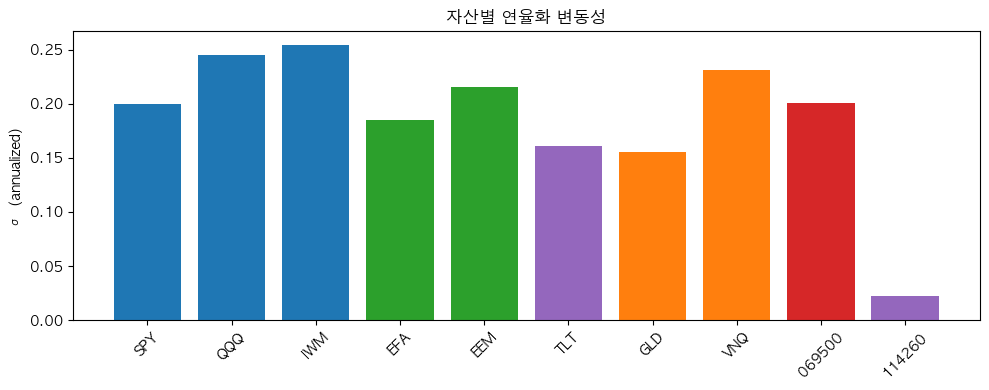

         연율화 변동성     자산군
IWM     0.254232   미국 주식
QQQ     0.244730   미국 주식
VNQ     0.230914      대안
EEM     0.215274  글로벌 주식
069500  0.200674      국내
SPY     0.199589   미국 주식
EFA     0.184652  글로벌 주식
TLT     0.160875      채권
GLD     0.155849      대안
114260  0.021892      채권


In [8]:
ann_vol = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
vol_df = ann_vol.rename("연율화 변동성").to_frame()
vol_df["자산군"] = [ticker_group(t) for t in vol_df.index]

fig, ax = plt.subplots(figsize=(10, 4))
colors = [GROUP_COLORS[g] for g in vol_df["자산군"]]
ax.bar(vol_df.index, vol_df["연율화 변동성"], color=colors)
ax.set_title("자산별 연율화 변동성")
ax.set_ylabel("σ (annualized)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close(fig)
print(vol_df.sort_values("연율화 변동성", ascending=False).round(6))


## 5. raw_features.parquet


In [9]:
expected_cols = []
for ticker in TICKERS:
    expected_cols.extend([
        f"{ticker}_return",
        f"{ticker}_RSI",
        f"{ticker}_MACD",
        f"{ticker}_MACD_signal",
    ])

missing_cols = [c for c in expected_cols if c not in raw_features.columns]
extra_cols = [c for c in raw_features.columns if c not in expected_cols]
print(f"기대 컬럼 수: {len(expected_cols)}, 실제: {len(raw_features.columns)}")
print(f"누락: {missing_cols or '없음'}")
print(f"returns 대비 시작일 지연: {(raw_features.index[0] - returns.index[0]).days} calendar days (~33거래일)")
print(f"행 수 차이 (returns - raw_features): {len(returns) - len(raw_features)}")


기대 컬럼 수: 40, 실제: 40
누락: 없음
returns 대비 시작일 지연: 51 calendar days (~33거래일)
행 수 차이 (returns - raw_features): 33


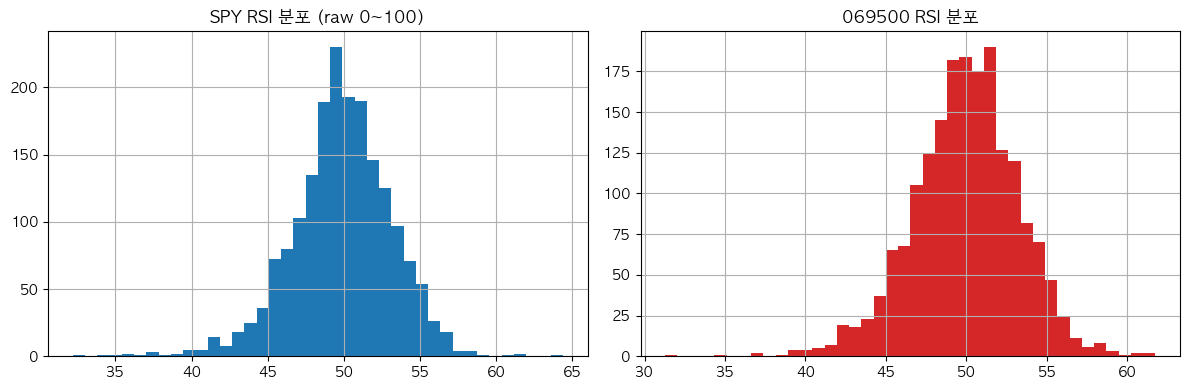

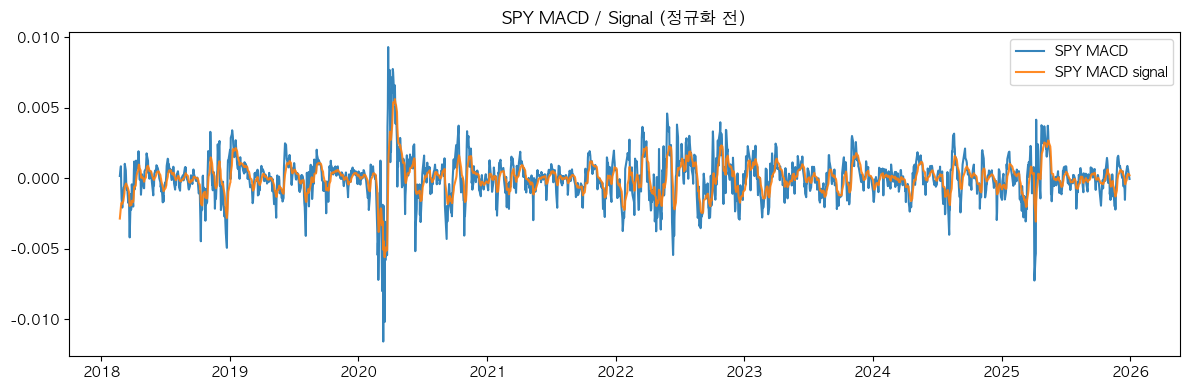

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_features["SPY_RSI"].hist(bins=40, ax=axes[0], color=GROUP_COLORS["미국 주식"])
axes[0].set_title("SPY RSI 분포 (raw 0~100)")
raw_features["069500_RSI"].hist(bins=40, ax=axes[1], color=GROUP_COLORS["국내"])
axes[1].set_title("069500 RSI 분포")
plt.tight_layout()
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw_features.index, raw_features["SPY_MACD"], label="SPY MACD", alpha=0.9)
ax.plot(raw_features.index, raw_features["SPY_MACD_signal"], label="SPY MACD signal", alpha=0.9)
ax.set_title("SPY MACD / Signal (정규화 전)")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)


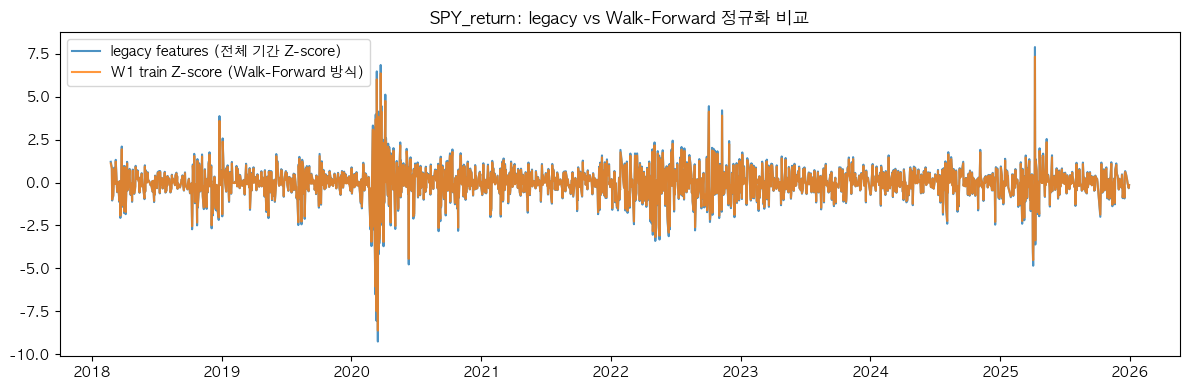

legacy 전체기간 mean/std: 0.0005669513203866483 0.012565517918123603
W1 train-only mean/std: 0.0006889058258140698 0.01350851008841907


In [11]:
# legacy features vs raw: look-ahead bias 설명용
common_idx = raw_features.index.intersection(features_legacy.index)
col = "SPY_return"
raw_col = raw_features.loc[common_idx, col]
legacy_col = features_legacy.loc[common_idx, col]

# 전체 기간 Z-score (legacy) vs W1 train-only Z-score
train_w1 = slice_period(raw_features, WINDOWS[0]["train_start"], WINDOWS[0]["train_end"])
w1_mean = train_w1[col].mean()
w1_std = train_w1[col].std() or 1.0
wf_normalized = (raw_col - w1_mean) / w1_std

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(common_idx, legacy_col, label="legacy features (전체 기간 Z-score)", alpha=0.8)
ax.plot(common_idx, wf_normalized, label="W1 train Z-score (Walk-Forward 방식)", alpha=0.8)
ax.set_title(f"{col}: legacy vs Walk-Forward 정규화 비교")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

print(
    "legacy 전체기간 mean/std:",
    float(raw_col.mean()),
    float(raw_col.std(ddof=1)),
)
print(
    "W1 train-only mean/std:",
    float(w1_mean),
    float(w1_std),
)


## 6. Walk-Forward 윈도우별 요약


In [12]:
wf_rows: list[dict[str, object]] = []
for window in WINDOWS:
  test_returns = slice_period(returns, window["test_start"], window["test_end"])
  ew = equal_weight_portfolio(test_returns)
  cum_ew = ew.cumsum()
  wf_rows.append(
      {
          "Window": window["name"],
          "Test": f"{window['test_start'][:4]}",
          "시장 국면": window["regime"],
          "거래일": len(test_returns),
          "EW 연수익(근사)": annualized_return(ew),
          "EW 연변동성": annualized_vol(ew),
          "EW MDD": max_drawdown(cum_ew),
      }
  )

wf_summary = pd.DataFrame(wf_rows)
print(wf_summary.round(4).to_string(index=False))


Window Test              시장 국면  거래일  EW 연수익(근사)  EW 연변동성  EW MDD
    W1 2022 금리 인상·주식·장기채 동반 약세  237     -0.2295   0.1610 -0.2494
    W2 2023       금리 충격 이후 회복장  237      0.1715   0.1022 -0.1035
    W3 2024   고금리 지속·기술주·AI 랠리  236      0.0804   0.0981 -0.0616
 Final 2025           최신 시장 구간  233      0.2522   0.1162 -0.1133


In [13]:
for window in WINDOWS:
    test_returns = slice_period(returns, window["test_start"], window["test_end"])
    per_asset = test_returns.sum().rename("test 누적 log return")
    per_asset_df = per_asset.to_frame()
    per_asset_df["자산군"] = [ticker_group(t) for t in per_asset_df.index]
    print(f"\n=== {window['name']} test ({window['test_start']} ~ {window['test_end']}) — {window['regime']} ===")
    print(per_asset_df.sort_values("test 누적 log return", ascending=False).round(4).to_string())



=== W1 test (2022-01-01 ~ 2022-12-31) — 금리 인상·주식·장기채 동반 약세 ===
        test 누적 log return     자산군
GLD                -0.0056      대안
114260             -0.0250      채권
EFA                -0.1459  글로벌 주식
SPY                -0.2005   미국 주식
EEM                -0.2212  글로벌 주식
IWM                -0.2286   미국 주식
069500             -0.2764      국내
VNQ                -0.2945      대안
TLT                -0.3613      채권
QQQ                -0.3998   미국 주식

=== W2 test (2023-01-01 ~ 2023-12-31) — 금리 충격 이후 회복장 ===
        test 누적 log return     자산군
QQQ                 0.4411   미국 주식
SPY                 0.2328   미국 주식
069500              0.2220      국내
IWM                 0.1692   미국 주식
EFA                 0.1572  글로벌 주식
GLD                 0.1257      대안
VNQ                 0.1167      대안
EEM                 0.0723  글로벌 주식
114260              0.0510      채권
TLT                 0.0252      채권

=== W3 test (2024-01-01 ~ 2024-12-31) — 고금리 지속·기술주·AI 랠리 ===
        test 누적 log return     자산군
QQQ        

In [ ]:
# W1 scaler spot check
scaler_path = SCALERS_DIR / "w1_feature_stats.json"
if scaler_path.exists():
    with open(scaler_path, encoding="utf-8") as f:
        saved = json.load(f)
    train_w1 = slice_period(raw_features, WINDOWS[0]["train_start"], WINDOWS[0]["train_end"])
    for col in ["SPY_return", "069500_RSI"]:
        calc_mean = float(train_w1[col].mean())
        calc_std = float(train_w1[col].std() or 1.0)
        saved_mean = float(saved["mean"][col])
        saved_std = float(saved["std"][col])
        print(
            f"{col}: saved mean={saved_mean:.8f} calc={calc_mean:.8f} | "
            f"saved std={saved_std:.8f} calc={calc_std:.8f}"
        )
else:
    print("scaler 파일 없음 — train_walkforward 실행 후 재확인")


## 7. 리포트용 요약 (섹션 2 초안)

**자산·기간**: 문서 기준 10개 ETF/ETF형 자산(SPY·QQQ·IWM·EFA·EEM·TLT·GLD·VNQ·069500·114260)을 2018-01-01~2025-12-31 구간에서 수집하였다. 해외 8종은 yfinance 수정종가(Adj Close), 국내 2종은 pykrx 종가를 사용하고 US–KR **inner join** 거래일로 병합한 뒤 forward fill·잔여 결측 제거 후 로그수익률을 산출하였다.

**피처**: RSI(14), MACD(12/26/9)를 포함한 40열 `raw_features.parquet`를 생성하고, Walk-Forward 학습 구간 통계로만 Z-score를 적용한다. `features.parquet`(전체 기간 Z-score)는 EDA·호환용이며 RL 학습에 직접 쓰지 않는다.

**권장 figure (PDF 섹션 2)**:
1. 정규화 가격 추이 (§3)
2. 상관 히트맵 + 누적 로그수익률(테스트 연도 표시) (§4)
3. 연율화 변동성 막대 (§4)
4. legacy vs Walk-Forward 정규화 비교 (§5)
5. Walk-Forward test 구간 EW 성과 표 (§6)
